# 00 — M0/M1: Temeller ve I-JEPA anatomisi

Bu notebook'un amacı bir skor üretmek değil; **token akışını, stop-gradient sınırını, EMA teacher güncellemesini ve output-space masking'i** elle doğrulamaktır. Hücreleri sırayla çalıştırın. `Tahmin → Çalıştır → İncele` duraklarında cevabı önce kendiniz yazın.

Kısa akış CPU/MPS/Kaggle GPU üzerinde çalışır. Son bölümdeki resmî Meta smoke hücresi ayrı process kullanır; upstream kaynakları değiştirmez.

In [14]:
import os
import torch

print("Çalışma dizini:", os.getcwd())
print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.cuda.is_available())

Çalışma dizini: /kaggle/working/jepa-study
Torch: 2.10.0+cu128
GPU: Tesla T4
CUDA: True


In [15]:
from pathlib import Path
import os
import sys

ROOT = Path("/kaggle/working/jepa-study")

assert ROOT.is_dir(), f"Repo bulunamadı: {ROOT}"
assert (ROOT / "src/jepa_lab").is_dir(), "jepa_lab kaynak dizini bulunamadı."

os.chdir(ROOT)

src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

os.environ["JEPA_LAB_ROOT"] = str(ROOT)

print("Çalışma dizini:", os.getcwd())
print("Python:", sys.executable)
print("src path:", src_path)

Çalışma dizini: /kaggle/working/jepa-study
Python: /usr/bin/python3
src path: /kaggle/working/jepa-study/src


In [16]:
%pip install -e /kaggle/working/jepa-study --no-deps

Obtaining file:///kaggle/working/jepa-study
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jepa-lab (pyproject.toml) ... done
  Created wheel for jepa-lab: filename=jepa_lab-0.1.0-0.editable-py3-none-any.whl size=10735 sha256=f07588438936ed2ded21ad1612c39801ebf80d7c03118138638b059beedada3f
  Stored in directory: /tmp/pip-ephem-wheel-cache-80izfj_i/wheels/71/84/04/b9b66b6bf3b1c05d1e0fce6c135d7ddba4eb6e075284d68a81
Successfully built jepa-lab
  Attempting uninstall: jepa-lab
    Found existing installation: jepa-lab 0.1.0
    Uninstalling jepa-lab-0.1.0:
      Successfully uninstalled jepa-lab-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [18]:
import jepa_lab

print("jepa_lab:", jepa_lab.__file__)

jepa_lab: /kaggle/working/jepa-study/src/jepa_lab/__init__.py


## Ortamı bul

Notebook'u repo içinde açın. Kaggle için önerilen yol `/kaggle/working/jepa-study`, Colab için `/content/jepa-study`'dir. Farklı bir yerdeyse `JEPA_LAB_ROOT` ortam değişkenini ayarlayabilirsiniz.

In [19]:
from pathlib import Path
import os, sys

override = os.environ.get('JEPA_LAB_ROOT')
candidates = ([Path(override)] if override else []) + [
    Path.cwd(), *Path.cwd().parents,
    Path('/kaggle/working/jepa-study'), Path('/kaggle/working/I-JEPA'),
    Path('/content/jepa-study'), Path('/content/I-JEPA'),
]
ROOT = next((p.resolve() for p in candidates if (p / 'pyproject.toml').is_file()), None)
if ROOT is None:
    raise RuntimeError('Repo bulunamadı; JEPA_LAB_ROOT değişkenini repo yoluna ayarlayın.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
print('repo:', ROOT)

repo: /kaggle/working/jepa-study


## Tahmin 1 — Token sayısı

Çalıştırmadan önce cevaplayın:

1. `224×224` bir görüntü `16×16` patch'lere bölünürse kaç token oluşur?
2. `16×224×224` video, `2×16×16` tubelet ile kaç `(t,h,w)` token üretir?
3. Video tensörünün laboratuvar sözleşmesi hangi eksen sırasındadır?

In [20]:
print(f'token count: {int(224/16)} X {int(224/16)} = {int(224/16*224/16)}')
print(f'tubelet: {int(16/2)} X {int(224/16)} X {int(224/16)}')
print(int(8*14*14))

token count: 14 X 14 = 196
tubelet: 8 X 14 X 14
1568


In [21]:
from pprint import pprint
from jepa_lab.foundations import foundation_report

report = foundation_report()
pprint(report)
assert report['image_tokens_224_p16'] == 196
assert tuple(report['video_grid_16x224_t2_p16']) == (8, 14, 14)
assert report['video_tokens_16x224_t2_p16'] == 1568

{'ema_example': {'momentum': 0.9,
                 'online': 2.0,
                 'target_after': 1.1,
                 'target_before': 1.0},
 'environment': {'cuda_arch_compatible': True,
                 'cuda_available': True,
                 'cuda_compute_capability': [7, 5],
                 'cuda_device': 'Tesla T4',
                 'cuda_vram_gib': 14.56,
                 'machine': 'x86_64',
                 'mps_available': False,
                 'platform': 'Linux-6.12.90+-x86_64-with-glibc2.35',
                 'python': '3.12.13',
                 'recommended_device': 'cuda',
                 'torch': '2.10.0+cu128',
                 'torch_cuda_arch_list': ['sm_70',
                                          'sm_75',
                                          'sm_80',
                                          'sm_86',
                                          'sm_90',
                                          'sm_100',
                                          'sm_120

### İncele 1

Canonical video biçimi `[B,T,C,H,W]`; Meta V-JEPA adapter'ı bunu upstream için `[B,C,T,H,W]` biçimine çevirir. `8×14×14=1568` hesabını ezberlemek yerine tubelet'in temporal stride'ını neden ikiye böldüğünü açıklayın.

## Tahmin 2 — I-JEPA maskeleri

Dört target blok birbirleriyle örtüşebilir. Fakat context ile target neden ayrık olmalıdır? Görselde `0=context`, `1..4=target block`, `-1=kullanılmayan patch` olacaktır. Önce haritanın yaklaşık nasıl görüneceğini çizin.

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from jepa_lab.device import seed_everything, select_device
from jepa_lab.masking import MultiBlockMasker
from jepa_lab.visualization import plot_image_masks

batch_size = 2

seed_everything(42)
device = select_device('auto')
masker = MultiBlockMasker(
    (8, 8), num_targets=4, target_scale=(0.15, 0.20), context_scale=(0.85, 1.0)
)
masks = masker(batch_size, generator=torch.Generator().manual_seed(42), device=device)

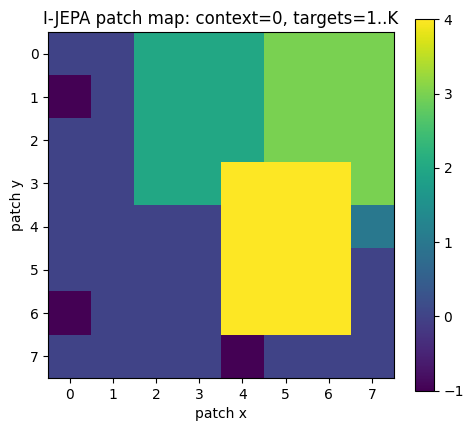

context shape: (2, 27)
targets shape: (2, 4, 12)
context-target disjoint: True
target-target overlap exists: True

Batch örneği 0 — context indeksleri (27):
[63, 62, 9, 40, 33, 58, 49, 17, 57, 47, 32, 51, 34, 50, 42, 43, 16, 56, 41, 59, 61, 0, 55, 24, 35, 25, 1]
Target 1 indeksleri (12): [13, 14, 15, 21, 22, 23, 29, 30, 31, 37, 38, 39]
Target 2 indeksleri (12): [2, 3, 4, 10, 11, 12, 18, 19, 20, 26, 27, 28]
Target 3 indeksleri (12): [5, 6, 7, 13, 14, 15, 21, 22, 23, 29, 30, 31]
Target 4 indeksleri (12): [28, 29, 30, 36, 37, 38, 44, 45, 46, 52, 53, 54]
Target 1 ∩ Target 3: [13, 14, 15, 21, 22, 23, 29, 30, 31]
Target 1 ∩ Target 4: [29, 30, 37, 38]
Target 2 ∩ Target 4: [28]
Target 3 ∩ Target 4: [29, 30]


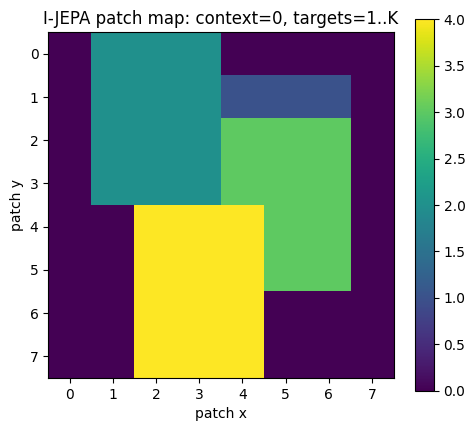

context shape: (2, 27)
targets shape: (2, 4, 12)
context-target disjoint: True
target-target overlap exists: True

Batch örneği 1 — context indeksleri (27):
[0, 4, 5, 6, 7, 8, 15, 16, 23, 24, 31, 32, 33, 39, 40, 41, 47, 48, 49, 53, 54, 55, 56, 57, 61, 62, 63]
Target 1 indeksleri (12): [12, 13, 14, 20, 21, 22, 28, 29, 30, 36, 37, 38]
Target 2 indeksleri (12): [1, 2, 3, 9, 10, 11, 17, 18, 19, 25, 26, 27]
Target 3 indeksleri (12): [20, 21, 22, 28, 29, 30, 36, 37, 38, 44, 45, 46]
Target 4 indeksleri (12): [34, 35, 36, 42, 43, 44, 50, 51, 52, 58, 59, 60]
Target 1 ∩ Target 3: [20, 21, 22, 28, 29, 30, 36, 37, 38]
Target 1 ∩ Target 4: [36]
Target 3 ∩ Target 4: [36, 44]


In [23]:
for i in range(batch_size):
  sample = i  # Batch içindeki hangi görüntünün maskesini inceleyeceğiz?
  mask_figure = plot_image_masks(masks, sample=sample)
  display(mask_figure)
  plt.close(mask_figure)  # Inline backend'in aynı figürü ikinci kez çizmesini engeller.

  context_indices = masks.context[sample].cpu().tolist()
  target_indices = masks.targets[sample].cpu().tolist()
  context_set = set(context_indices)
  target_sets = [set(block) for block in target_indices]
  print('context shape:', tuple(masks.context.shape))
  print('targets shape:', tuple(masks.targets.shape))
  print('context-target disjoint:', all(context_set.isdisjoint(t) for t in target_sets))
  print('target-target overlap exists:', any(target_sets[i] & target_sets[j] for i in range(4) for j in range(i+1, 4)))
  print(f'\nBatch örneği {sample} — context indeksleri ({len(context_indices)}):')
  print(context_indices)
  for block_id, indices in enumerate(target_indices, start=1):
      print(f'Target {block_id} indeksleri ({len(indices)}): {indices}')
  for first in range(len(target_sets)):
      for second in range(first + 1, len(target_sets)):
          overlap = sorted(target_sets[first] & target_sets[second])
          if overlap:
              print(f'Target {first + 1} ∩ Target {second + 1}: {overlap}')

### İncele 2 — Maskeyi görüntü üzerinde gör

Aşağıdaki çizim öğretici bir gösterimdir: solda özgün görüntü, ortada yalnız context patch'leri, sağda ise target blokların şeffaf katmanları vardır. Örtüşen patch'lerde `1+3` gibi etiketler görünür. Gerçek forward akışında target encoder tam görüntüyü kodlar; context encoder ise maskenin seçtiği patch token'larını alır.

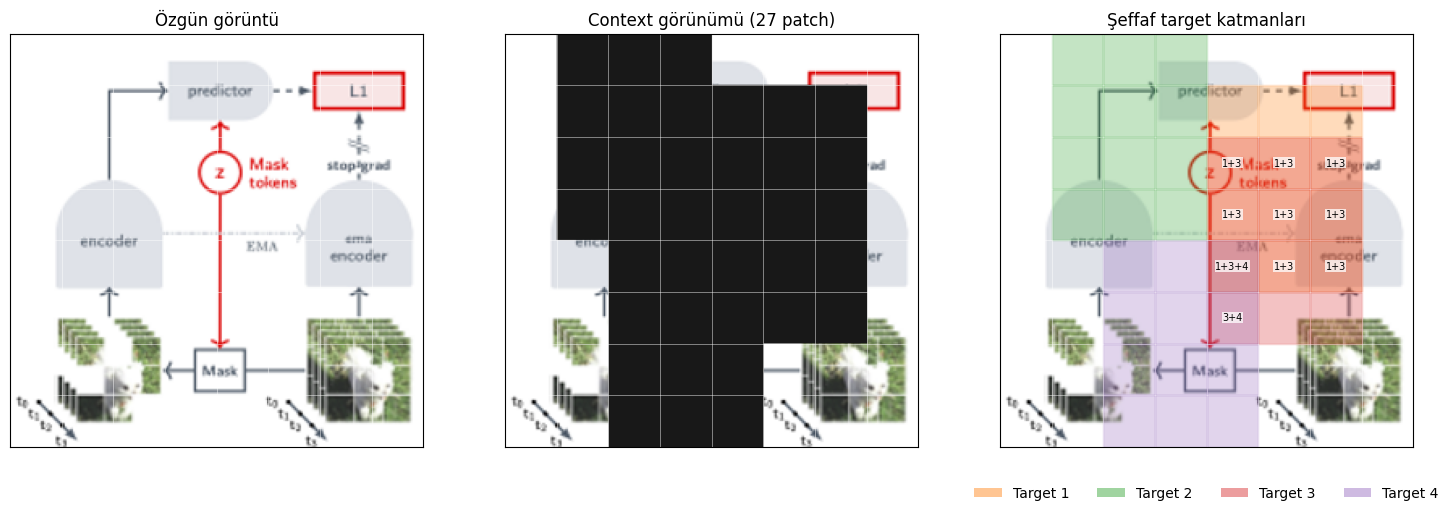

In [24]:
from collections import defaultdict
from PIL import Image, ImageOps
from matplotlib.patches import Patch, Rectangle
import numpy as np

image_path = ROOT / 'upstream/vjepa2/assets/vjepa2-abstract-new.png'
if not image_path.is_file():
    raise FileNotFoundError(f'Örnek görüntü bulunamadı: {image_path}')

image = ImageOps.fit(Image.open(image_path).convert('RGB'), (256, 256))
image_array = np.asarray(image)
grid_height, grid_width = masks.grid_size
patch_height = image_array.shape[0] // grid_height
patch_width = image_array.shape[1] // grid_width

context_view = np.full_like(image_array, 24)
for index in context_indices:
    y, x = divmod(index, grid_width)
    y0, y1 = y * patch_height, (y + 1) * patch_height
    x0, x1 = x * patch_width, (x + 1) * patch_width
    context_view[y0:y1, x0:x1] = image_array[y0:y1, x0:x1]

memberships = defaultdict(list)
for block_id, indices in enumerate(target_indices, start=1):
    for index in indices:
        memberships[index].append(block_id)

colors = plt.get_cmap('tab10').colors[1:5]
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_array)
axes[0].set_title('Özgün görüntü')
axes[1].imshow(context_view)
axes[1].set_title(f'Context görünümü ({len(context_indices)} patch)')
axes[2].imshow(image_array)
axes[2].set_title('Şeffaf target katmanları')

for block_id, indices in enumerate(target_indices, start=1):
    color = colors[block_id - 1]
    for index in indices:
        y, x = divmod(index, grid_width)
        axes[2].add_patch(Rectangle(
            (x * patch_width - 0.5, y * patch_height - 0.5),
            patch_width, patch_height, facecolor=color, edgecolor=color,
            linewidth=1.0, alpha=0.28,
        ))

for index, blocks in memberships.items():
    if len(blocks) > 1:
        y, x = divmod(index, grid_width)
        axes[2].text(
            (x + 0.5) * patch_width - 0.5,
            (y + 0.5) * patch_height - 0.5,
            '+'.join(map(str, blocks)), ha='center', va='center', fontsize=7,
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 0.5},
        )

for axis in axes:
    axis.set_xticks(np.arange(0, image_array.shape[1] + 1, patch_width) - 0.5)
    axis.set_yticks(np.arange(0, image_array.shape[0] + 1, patch_height) - 0.5)
    axis.grid(color='white', linewidth=0.5, alpha=0.65)
    axis.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

axes[2].legend(
    handles=[Patch(facecolor=colors[i], alpha=0.45, label=f'Target {i + 1}') for i in range(4)],
    loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False,
)
figure.tight_layout()
plt.show()

## Tahmin 3 — Forward akışı

Aşağıdaki model `64/8=8` patch grid kullanır. Teacher'ın gördüğü token sayısı ile context encoder'ın gördüğü token sayısını tahmin edin. Target seçimi görüntü üzerinde mi, teacher encoder çıktısında mı yapılmalıdır?

In [25]:
from jepa_lab.image_jepa import ImageJEPA

model = ImageJEPA(
    image_size=64, patch_size=8, embed_dim=64,
    encoder_depth=2, encoder_heads=4,
    predictor_dim=64, predictor_depth=2, predictor_heads=4,
).to(device)
images = torch.randn(2, 3, 64, 64, device=device)
with torch.no_grad():
    full_teacher = model.target_encoder(images)
output = model(images, masks)
print('full teacher [B,N,D]:', tuple(full_teacher.shape))
print('context [B,Nc,D]:', tuple(output.context.shape))
print('prediction [B,K,Nt,D]:', tuple(output.predicted.shape))
print('selected target:', tuple(output.target.shape))
print('SmoothL1:', float(output.loss.detach()))
assert full_teacher.shape[1] == 64
assert output.predicted.shape == output.target.shape

full teacher [B,N,D]: (2, 64, 64)
context [B,Nc,D]: (2, 27, 64)
prediction [B,K,Nt,D]: (2, 4, 12, 64)
selected target: (2, 4, 12, 64)
SmoothL1: 0.5244476795196533


### İncele 3

Kritik ayrım: target encoder **tam görüntüyü** kodlar; hedef patch'ler latent çıktıdan seçilir. Resmî kod, paper'daki yalın squared-L2 anlatımından farklı olarak target'a parametresiz LayerNorm ve `SmoothL1` uygular.

## Tahmin 4 — Gradient ve EMA

Backward sonrasında hangi modüllerde gradient bekliyorsunuz: context encoder, predictor, target encoder? Momentum `m=0.996` iken target parametresinin yeni değeri hangi iki parametrenin ağırlıklı toplamıdır?

In [26]:
from dataclasses import asdict
from jepa_lab.image_jepa import train_one_step

optimizer = torch.optim.AdamW(model.trainable_parameters(), lr=1e-3)
step_result = train_one_step(model, images, masks, optimizer, ema_momentum=0.996)
pprint(asdict(step_result))
assert step_result.context_grad_norm > 0
assert step_result.predictor_grad_norm > 0
assert not step_result.target_has_grad
assert step_result.all_finite
assert step_result.ema_max_error < 1e-6

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'all_finite': True,
 'context_grad_norm': 0.5317831970048456,
 'ema_max_error': 1.4901161193847656e-08,
 'loss': 0.5244477391242981,
 'predictor_grad_norm': 1.0823606012297944,
 'target_has_grad': False}


## Resmî Meta I-JEPA smoke — ayrı process

Bu hücre büyük checkpoint indirmez; pinned `facebookresearch/ijepa` bileşenleriyle tek bir gerçek forward/backward adımı çalıştırır. CPU'da da çalışır fakat birkaç dakika sürebilir. Upstream `src` namespace çakışmasını önlemek için subprocess zorunludur. `RUN_OFFICIAL=True` yaparak bilinçli biçimde başlatın.

In [27]:
import subprocess

RUN_OFFICIAL = True
if RUN_OFFICIAL:
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_ijepa_smoke.py'),
        '--device', str(device), '--image-size', '112', '--batch-size', '1',
    ], cwd=ROOT, check=True)
else:
    print('Atlandı. Hazır olduğunuzda RUN_OFFICIAL=True yapın.')

INFO:root:VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
)


{
  "implementation": "facebookresearch/ijepa@52c1ae95",
  "device": "cuda",
  "image_shape": [
    1,
    3,
    112,
    112
  ],
  "full_target_shape": [
    1,
    49,
    192
  ],
  "context_shape": [
    1,
    12,
    192
  ],
  "prediction_shape": [
    4,
    9,
    192
  ],
  "target_shape": [
    4,
    9,
    192
  ],
  "context_tokens": 12,
  "target_tokens_each": [
    9,
    9,
    9,
    9
  ],
  "context_target_disjoint": true,
  "target_target_overlap_allowed": true,
  "loss": 0.446709543466568,
  "encoder_grad_norm": 0.01947690360248089,
  "predictor_grad_norm": 0.5253385901451111,
  "target_has_grad": false,
  "ema_max_abs_error": 1.1920928955078125e-07,
  "target_masking_location": "target encoder output",
  "target_normalization": "feature-wise layer_norm",
  "loss_function": "smooth_l1"
}


## Resmî pretrained I-JEPA encoder feature'ları

Checkpoint'i `configs/checkpoints.yaml` içindeki resmî URL'den indirin. ViT-H/14 büyük olduğu için bu hücre Kaggle GPU içindir. Script patch latent'lerini, mean-pooling cosine değerlerini, checkpoint SHA-256 ve missing/unexpected key listesini kaydeder. Random-init shape smoke ile pretrained sonucu aynı şey değildir.

Kaggle'da checkpoint'i private Dataset olarak notebook'a ekleyebilirsiniz; dosya `/kaggle/input/...` altında salt-okunur bağlanır ve `/kaggle/working` içine kopyalanması gerekmez. Aşağıdaki hücre sırasıyla `IJEPA_CHECKPOINT` ortam değişkenini, repo içindeki `checkpoints/` klasörünü ve bağlı Kaggle Dataset'lerini arar.

In [29]:
import os
import subprocess
from pathlib import Path

IJEPA_CHECKPOINT_NAMES = (
    'IN1K-vit.h.14-300e.pth.tar',  # Resmî dosya adı
    'IN1K-vit.h.14-300e.pth',      # Kaggle Dataset için güvenli yeniden adlandırma
    'IN1k-vit.h.14-300e.pth.tar',  # Kaggle'da küçük-k ile kaydedilmiş varyant
    'IN1k-vit.h.14-300e.pth',
)

def resolve_ijepa_checkpoint() -> Path:
    override = os.environ.get('IJEPA_CHECKPOINT')
    if override:
        path = Path(override).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f'IJEPA_CHECKPOINT dosyası bulunamadı: {path}')
        return path.resolve()

    for name in IJEPA_CHECKPOINT_NAMES:
        local = ROOT / 'checkpoints' / name
        if local.is_file():
            return local.resolve()

    kaggle_input = Path('/kaggle/input')
    matches = []
    if kaggle_input.is_dir():
        for name in IJEPA_CHECKPOINT_NAMES:
            matches.extend(kaggle_input.rglob(name))
        matches = sorted(set(matches))
    if len(matches) == 1:
        return matches[0].resolve()
    if len(matches) > 1:
        choices = '\n'.join(f'  - {path}' for path in matches)
        raise RuntimeError(
            'Birden fazla I-JEPA checkpoint bulundu. Kullanılacak yolu '
            f'IJEPA_CHECKPOINT ile belirtin:\n{choices}'
        )
    raise FileNotFoundError(
        f'{IJEPA_CHECKPOINT_NAMES[0]} bulunamadı. Kaggle Dataset bağlantısını '
        'Input panelinden ekleyin veya IJEPA_CHECKPOINT yolunu ayarlayın.'
    )

RUN_PRETRAINED_IJEPA = True
try:
    ijepa_checkpoint = resolve_ijepa_checkpoint()
    checkpoint_location = (
        'Kaggle Dataset'
        if str(ijepa_checkpoint).startswith('/kaggle/input/')
        else 'yerel dosya'
    )
    print(f'Checkpoint hazır ({checkpoint_location}): {ijepa_checkpoint}')
except FileNotFoundError as error:
    ijepa_checkpoint = None
    print(error)

if RUN_PRETRAINED_IJEPA:
    if ijepa_checkpoint is None:
        raise FileNotFoundError(
            'Resmî I-JEPA checkpoint bulunamadığı için pretrained çalışma başlatılamadı.'
        )
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_ijepa_features.py'),
        '--device', str(device), '--model', 'vit_huge', '--patch-size', '14',
        '--image-size', '224', '--checkpoint', str(ijepa_checkpoint),
        '--output', str(ROOT / 'runs/ijepa_pretrained_views.npz'),
    ], cwd=ROOT, check=True)
else:
    print('Atlandı. Checkpoint ve Kaggle GPU hazır olduğunda bayrağı açın.')

Checkpoint hazır (Kaggle Dataset): /kaggle/input/datasets/ercankurtoglu/i-jepa-vit-h14-checkpoint/ijepa-vith14-checkpoint/IN1K-vit.h.14-300e.pth
{
  "implementation": "facebookresearch/ijepa@52c1ae95",
  "weights": "pretrained",
  "device": "cuda",
  "model": "vit_huge",
  "patch_size": 14,
  "image_size": 224,
  "input_source": "deterministic synthetic image",
  "variant_order": [
    "normal",
    "crop",
    "color",
    "occluded"
  ],
  "stimulus_id": "shared-image-scene-v1",
  "feature_shape": [
    1,
    256,
    1280
  ],
  "expected_tokens": 256,
  "cosine_to_normal": {
    "normal": 1.0,
    "crop": 0.9923975467681885,
    "color": 0.9945201277732849,
    "occluded": 0.9746432304382324
  },
  "pooling": "mean over patch tokens for cosine; raw patch tokens exported",
  "preprocessing": "RGB, resize/center-crop, ImageNet mean/std",
  "load_result": {
    "checkpoint": "/kaggle/input/datasets/ercankurtoglu/i-jepa-vit-h14-checkpoint/ijepa-vith14-checkpoint/IN1K-vit.h.14-300e.pth

## Image Control

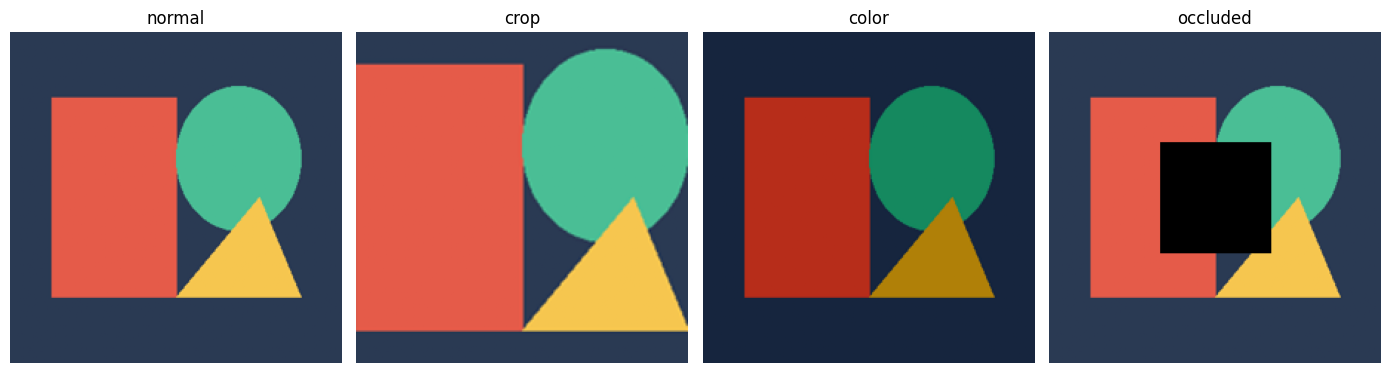

In [30]:
import matplotlib.pyplot as plt
from jepa_lab.stimuli import image_views

views = image_views(
    path=None,
    image_size=224,
)

figure, axes = plt.subplots(
    1,
    len(views),
    figsize=(14, 4),
)

for axis, (name, pixels) in zip(
    axes,
    views.items(),
):
    # [C,H,W] → [H,W,C]
    image = pixels.permute(1, 2, 0)

    axis.imshow(image)
    axis.set_title(name)
    axis.axis("off")

figure.tight_layout()
plt.show()

In [31]:
for name, pixels in views.items():
    print(
        name,
        pixels.shape,
        pixels.min().item(),
        pixels.max().item(),
    )

normal torch.Size([3, 224, 224]) 0.10588235408067703 1.0
crop torch.Size([3, 224, 224]) 0.06666667014360428 1.0
color torch.Size([3, 224, 224]) 0.003921568859368563 0.7607843279838562
occluded torch.Size([3, 224, 224]) 0.0 1.0


## Benzerlik Karşılaştırması

In [33]:
from pathlib import Path
import numpy as np

feature_path = Path(
    "/kaggle/working/jepa-study/runs/ijepa_pretrained_views.npz"
)

with np.load(feature_path, allow_pickle=False) as data:
    features = data["features"]
    labels = data["labels"]
    sample_ids = data["sample_ids"]

print("features:", features.shape)
print("labels:", labels)
print("sample_ids:", sample_ids)

features: (4, 256, 1280)
labels: [0 1 2 3]
sample_ids: ['shared-image-scene-v1/normal' 'shared-image-scene-v1/crop'
 'shared-image-scene-v1/color' 'shared-image-scene-v1/occluded']


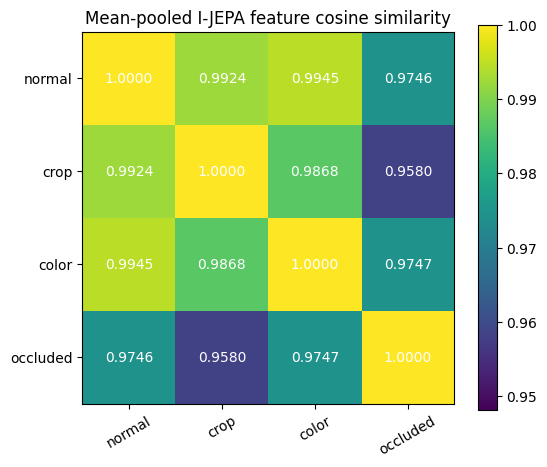

In [34]:
import matplotlib.pyplot as plt

names = ["normal", "crop", "color", "occluded"]

# [4, 256, 1280] -> [4, 1280]
global_features = features.mean(axis=1)

# Cosine için normalize et
global_features = global_features / (
    np.linalg.norm(global_features, axis=1, keepdims=True) + 1e-8
)

similarity = global_features @ global_features.T

fig, ax = plt.subplots(figsize=(6, 5))

# Değerler birbirine çok yakın olduğu için ölçek yakınlaştırılmıştır.
im = ax.imshow(
    similarity,
    cmap="viridis",
    vmin=max(0.90, similarity.min() - 0.01),
    vmax=1.0,
)

ax.set_xticks(range(4), names, rotation=30)
ax.set_yticks(range(4), names)

for row in range(4):
    for col in range(4):
        ax.text(
            col,
            row,
            f"{similarity[row, col]:.4f}",
            ha="center",
            va="center",
            color="white",
        )

ax.set_title("Mean-pooled I-JEPA feature cosine similarity")
plt.colorbar(im, ax=ax)
plt.show()

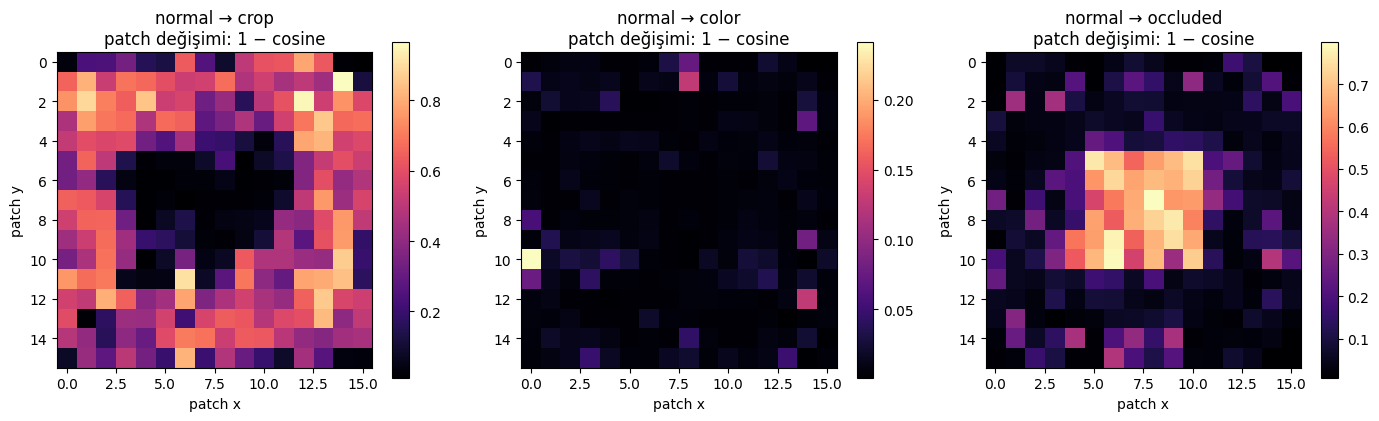

In [48]:
def patch_cosine(a, b):
    """
    a, b: [256, 1280]
    dönüş: [256]
    """
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return np.sum(a * b, axis=1)


normal = features[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, index, name in zip(
    axes,
    [1, 2, 3],
    ['crop', "color", "occluded"],
):
    similarity_per_patch = patch_cosine(
        normal,
        features[index],
    )

    change_map = (1.0 - similarity_per_patch).reshape(16, 16)

    im = ax.imshow(change_map, cmap="magma")
    ax.set_title(f"normal → {name}\npatch değişimi: 1 − cosine")
    ax.set_xlabel("patch x")
    ax.set_ylabel("patch y")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Gerçek fotoğraf deneyi: görünüm, feature ve negatif örnek

Bu deney iki farklı gerçek fotoğraf kullanır. İlk fotoğrafın `normal`, `crop`, `color` ve `occluded` görünümleri pozitif örneklerdir; ikinci fotoğraf ise negatif örnektir. Kaggle'da hazır gelen `scikit-learn` örnek fotoğrafları kullanıldığı için internetten indirme gerekmez. İsterseniz iki yolu kendi JPG/PNG dosyalarınızla değiştirebilirsiniz.

> Heatmap'te yalnız uzamsal olarak hizalı `color` ve `occluded` görünümleri kullanılır. `crop`, aynı patch indeksindeki görüntü içeriğini değiştirdiği için aynı-index patch heatmap'i yanıltıcı olabilir.

In [49]:
from pathlib import Path
from PIL import Image
from jepa_lab.stimuli import synthetic_image_scene

# Kendi dosyalarınızı kullanmak isterseniz bu iki değeri Path(...) yapın.
REAL_IMAGE_PATH = None
DIFFERENT_IMAGE_PATH = None

sample_directory = ROOT / 'runs' / 'real_image_samples'
sample_directory.mkdir(parents=True, exist_ok=True)

if REAL_IMAGE_PATH is None or DIFFERENT_IMAGE_PATH is None:
    try:
        from sklearn.datasets import load_sample_images
        sample_images = load_sample_images().images
        default_real = sample_directory / 'china.jpg'
        default_different = sample_directory / 'flower.jpg'
        Image.fromarray(sample_images[0]).save(default_real, quality=95)
        Image.fromarray(sample_images[1]).save(default_different, quality=95)
    except ImportError:
        # Minimal yerel kurulumda sklearn yoksa deney yine çalışır.
        from matplotlib.cbook import get_sample_data
        default_real = Path(get_sample_data('grace_hopper.jpg', asfileobj=False))
        default_different = sample_directory / 'synthetic_negative.jpg'
        synthetic_image_scene().save(default_different, quality=95)
        print('Not: İkinci gerçek fotoğraf için DIFFERENT_IMAGE_PATH ayarlayın.')
    REAL_IMAGE_PATH = REAL_IMAGE_PATH or default_real
    DIFFERENT_IMAGE_PATH = DIFFERENT_IMAGE_PATH or default_different

REAL_IMAGE_PATH = Path(REAL_IMAGE_PATH)
DIFFERENT_IMAGE_PATH = Path(DIFFERENT_IMAGE_PATH)
assert REAL_IMAGE_PATH.is_file(), REAL_IMAGE_PATH
assert DIFFERENT_IMAGE_PATH.is_file(), DIFFERENT_IMAGE_PATH
print('Ana fotoğraf:', REAL_IMAGE_PATH)
print('Farklı fotoğraf:', DIFFERENT_IMAGE_PATH)

Ana fotoğraf: /kaggle/working/jepa-study/runs/real_image_samples/china.jpg
Farklı fotoğraf: /kaggle/working/jepa-study/runs/real_image_samples/flower.jpg


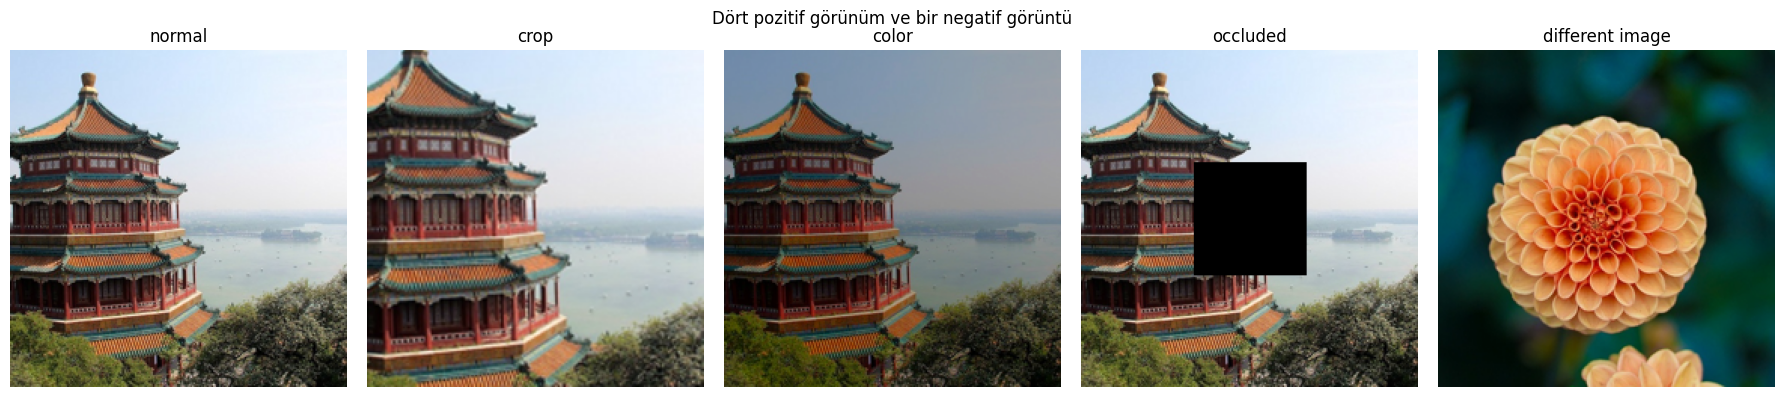

In [50]:
import matplotlib.pyplot as plt
from jepa_lab.stimuli import image_views

real_views = image_views(REAL_IMAGE_PATH, image_size=224)
different_normal = image_views(DIFFERENT_IMAGE_PATH, image_size=224)['normal']

display_views = list(real_views.items()) + [('different image', different_normal)]
figure, axes = plt.subplots(1, len(display_views), figsize=(18, 4))
for axis, (name, pixels) in zip(axes, display_views):
    axis.imshow(pixels.permute(1, 2, 0))
    axis.set_title(name)
    axis.axis('off')
figure.suptitle('Dört pozitif görünüm ve bir negatif görüntü')
figure.tight_layout()
plt.show()

In [51]:
# ViT-H/14 yalnız bir kez yüklenir; dört görünüm ve negatif görüntü aynı process'te kodlanır.
real_feature_path = ROOT / 'runs' / 'ijepa_real_image_views.npz'

subprocess.run([
    sys.executable, str(ROOT / 'scripts/official_ijepa_features.py'),
    '--device', str(device),
    '--model', 'vit_huge',
    '--patch-size', '14',
    '--image-size', '224',
    '--checkpoint', str(ijepa_checkpoint),
    '--image', str(REAL_IMAGE_PATH),
    '--comparison-image', str(DIFFERENT_IMAGE_PATH),
    '--output', str(real_feature_path),
], cwd=ROOT, check=True)

usage: official_ijepa_features.py [-h] [--device DEVICE]
                                  [--model {vit_tiny,vit_small,vit_base,vit_large,vit_huge}]
                                  [--patch-size PATCH_SIZE]
                                  [--image-size IMAGE_SIZE]
                                  [--checkpoint CHECKPOINT]
                                  [--state-key {target_encoder,encoder}]
                                  [--allow-incompatible] [--image IMAGE]
                                  [--output OUTPUT]
official_ijepa_features.py: error: unrecognized arguments: --comparison-image /kaggle/working/jepa-study/runs/real_image_samples/flower.jpg


CalledProcessError: Command '['/usr/bin/python3', '/kaggle/working/jepa-study/scripts/official_ijepa_features.py', '--device', 'cuda', '--model', 'vit_huge', '--patch-size', '14', '--image-size', '224', '--checkpoint', '/kaggle/input/datasets/ercankurtoglu/i-jepa-vit-h14-checkpoint/ijepa-vith14-checkpoint/IN1K-vit.h.14-300e.pth', '--image', '/kaggle/working/jepa-study/runs/real_image_samples/china.jpg', '--comparison-image', '/kaggle/working/jepa-study/runs/real_image_samples/flower.jpg', '--output', '/kaggle/working/jepa-study/runs/ijepa_real_image_views.npz']' returned non-zero exit status 2.

In [ ]:
import numpy as np

with np.load(real_feature_path, allow_pickle=False) as data:
    real_features = data['features']
    real_sample_ids = data['sample_ids']

view_names = ['normal', 'crop', 'color', 'occluded', 'different image']
assert real_features.shape == (5, 256, 1280), real_features.shape
print('Feature shape:', real_features.shape)
for name, sample_id in zip(view_names, real_sample_ids):
    print(f'{name:16s} -> {sample_id}')

In [ ]:
# 256 patch token'ı ortalanır: [5, 256, 1280] -> [5, 1280]
pooled = real_features.mean(axis=1)
pooled = pooled / (np.linalg.norm(pooled, axis=1, keepdims=True) + 1e-8)
similarity = pooled @ pooled.T

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

matrix = axes[0].imshow(similarity, cmap='viridis', vmin=-1.0, vmax=1.0)
axes[0].set_xticks(range(5), view_names, rotation=35, ha='right')
axes[0].set_yticks(range(5), view_names)
axes[0].set_title('Global feature cosine matrisi')
for row in range(5):
    for column in range(5):
        axes[0].text(column, row, f'{similarity[row, column]:.3f}',
                     ha='center', va='center', color='white')
figure.colorbar(matrix, ax=axes[0], label='cosine similarity')

normal_similarities = similarity[0, 1:]
bar_colors = ['tab:blue', 'tab:blue', 'tab:blue', 'tab:orange']
axes[1].bar(view_names[1:], normal_similarities, color=bar_colors)
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].set_ylim(-1.0, 1.0)
axes[1].set_ylabel('normal ile cosine similarity')
axes[1].set_title('Pozitif görünümler ve negatif görüntü')
axes[1].tick_params(axis='x', rotation=35)
for index, value in enumerate(normal_similarities):
    axes[1].text(index, value, f'{value:.3f}', ha='center', va='bottom')

figure.tight_layout()
plt.show()

positive_mean = float(normal_similarities[:3].mean())
negative_similarity = float(normal_similarities[3])
print(f'Pozitif ortalama: {positive_mean:.4f}')
print(f'Negatif benzerlik: {negative_similarity:.4f}')
print(f'Ayrım (pozitif - negatif): {positive_mean - negative_similarity:.4f}')

In [ ]:
def patch_cosine_numpy(left, right):
    left = left / (np.linalg.norm(left, axis=1, keepdims=True) + 1e-8)
    right = right / (np.linalg.norm(right, axis=1, keepdims=True) + 1e-8)
    return np.sum(left * right, axis=1)

# Color ve occlusion geometrik hizayı korur; aynı patch indekslerini karşılaştırabiliriz.
aligned = [('color', 2), ('occluded', 3)]
change_maps = {
    name: (1.0 - patch_cosine_numpy(real_features[0], real_features[index])).reshape(16, 16)
    for name, index in aligned
}
shared_max = max(float(np.percentile(change, 99)) for change in change_maps.values())

figure, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (name, _) in enumerate(aligned):
    image = real_views[name].permute(1, 2, 0).numpy()
    change = change_maps[name]
    enlarged = np.repeat(np.repeat(change, 14, axis=0), 14, axis=1)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f'{name} görünümü')

    heat = axes[row, 1].imshow(change, cmap='magma', vmin=0.0, vmax=shared_max)
    axes[row, 1].set_title('Patch değişimi: 1 − cosine')
    axes[row, 1].set_xlabel('patch x')
    axes[row, 1].set_ylabel('patch y')

    axes[row, 2].imshow(image)
    axes[row, 2].imshow(enlarged, cmap='magma', alpha=0.55, vmin=0.0, vmax=shared_max)
    axes[row, 2].set_title('Görüntü + feature değişimi')

    axes[row, 0].axis('off')
    axes[row, 2].axis('off')

figure.colorbar(heat, ax=axes[:, 1:], shrink=0.75, label='1 − patch cosine')
figure.suptitle('I-JEPA patch-level duyarlılık haritası')
plt.show()

### Sonuçları nasıl okuyacağız?

- `normal–crop/color/occluded` benzerlikleri **pozitif çiftlerdir**: aynı sahnenin değişmiş görünümleri.
- `normal–different image` **negatif çifttir**: farklı içerik. İyi bir ayrım için pozitif ortalamanın negatif benzerlikten yüksek olmasını bekleriz. Tek çift kanıt değildir; sonraki doğru adım bunu çok sayıda görüntü üzerinde dağılım olarak ölçmektir.
- Heatmap parlaklığı attention değildir. Parlak patch, son encoder temsilinin normale göre daha fazla değiştiğini gösterir.
- Occlusion dışındaki alanların da değişmesi normaldir; transformer token'ları self-attention ile tüm görüntüden bağlam alır.

Literatürde ve temsil analizlerinde kullanılabilecek sonraki incelemeler:

1. **PCA/UMAP:** Çok sayıda görüntünün global feature'larını 2B'ye indirip sınıfların veya sahnelerin kümelenmesini gözlemek.
2. **Nearest-neighbor retrieval:** Bir sorgu görüntüsüne feature uzayında en yakın gerçek görüntüleri göstermek.
3. **Pozitif-negatif dağılımları:** Yüzlerce aynı-görüntü varyasyonu ve farklı-görüntü çifti için cosine histogramı ve aralarındaki marjı ölçmek.
4. **Linear probe:** Encoder'ı dondurup mean-pooled feature üzerinde küçük bir doğrusal sınıflandırıcı eğitmek; I-JEPA makalesindeki temel değerlendirmeye en yakın deney budur.
5. **Patch correspondence:** Crop gibi geometrik dönüşümlerde aynı indeks yerine her crop patch'i için normal görüntüde en benzer patch'i aramak.
6. **Pretrained–random baseline:** Aynı grafikleri pretrained ve random-init encoder ile üretmek; yalnız görsel olarak düzenli görünen haritaların gerçekten öğrenilmiş olup olmadığını sınamak.

## M0/M1 geçiş kontrolü

Bir sonraki notebook'a geçmeden önce şu cümleleri şekillerle açıklayabilmelisiniz:

- `224/16 → 14×14=196`; video için `16/2×14×14=1568`.
- Context encoder yalnız görünen patch'leri, EMA target encoder tam görüntüyü görür.
- Target seçimi encoder çıkışında yapılır; target gradient almaz.
- Predictor konum bilgisini mask token/position embedding üzerinden alır.
- EMA bir optimizer adımı değildir; online parametreleri yavaşça target'a taşır.